# Infernece Script

In [ ]:
import torch
from transformers import BertTokenizer
from PIL import Image
from torchvision import transforms
import numpy as np
import pandas as pd
import seaborn as sns
import ast
import os
import random
import time
import requests
import re
import nltk
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from collections import Counter
import requests
import os
import re
import time
import random
from PIL import Image
from io import BytesIO
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms
from sklearn.preprocessing import MultiLabelBinarizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

import warnings
# from model import MultiModalGenreClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = MultiModalGenreClassifier().to(device)
model.load_state_dict(torch.load("best_model_checkpoint.pth", map_location=device))
model.eval()


GENRE_CLASSES = sorted([
    'Drama', 'Science Fiction', 'Adventure', 'History', 'Animation', 'Mystery',
    'Comedy', 'Western', 'TV Movie', 'Music', 'Foreign', 'Thriller', 'Family',
    'Documentary', 'Action', 'Romance', 'Fantasy', 'War', 'Horror', 'Crime'
])
threshold = 0.5


tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


def preprocess_inputs(image_path, text):
    image = Image.open(image_path).convert("RGB")
    image_tensor = image_transform(image).unsqueeze(0).to(device)

    tokens = tokenizer(text, return_tensors="pt", padding='max_length', truncation=True, max_length=128)
    input_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    return image_tensor, input_ids, attention_mask


def predict_genres(image_path, overview_text):
    image_tensor, input_ids, attention_mask = preprocess_inputs(image_path, overview_text)

    with torch.no_grad():
        output = model(image_tensor, input_ids, attention_mask)
        predicted = (output > threshold).int().squeeze(0).cpu().numpy()

    predicted_genres = [GENRE_CLASSES[i] for i, val in enumerate(predicted) if val == 1]
    return predicted_genres


/Users/mahesh/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mahesh/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/mahesh/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
overview = "Siblings Judy and Peter discover an enchanted board game that opens a magical world..."
image_path = "/content/drive/MyDrive/movie_recommendation/Wonka.jpg"

predicted = predict_genres(image_path, overview)
print("Predicted Genres:", predicted)


Predicted Genres: ['Animation', 'Comedy', 'Family', 'Fantasy']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiModalGenreClassifier().to(device)
model.load_state_dict(torch.load("final_model.pt", map_location=device))
model.eval()

GENRE_CLASSES = sorted([
    'Drama', 'Science Fiction', 'Adventure', 'History', 'Animation', 'Mystery',
    'Comedy', 'Western', 'TV Movie', 'Music', 'Foreign', 'Thriller', 'Family',
    'Documentary', 'Action', 'Romance', 'Fantasy', 'War', 'Horror', 'Crime'
])
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


df = pd.read_csv("/content/drive/MyDrive/movie_recommendation/tmdb_cleaned.csv")
df = df[df['poster_paths'] != "Poster Not Found"].reset_index(drop=True)
df['genre_list'] = df['genre_list'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


predicted_genres_list = []

with torch.no_grad():
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Predicting genres"):

        image = Image.open(row['poster_paths']).convert("RGB")
        image_tensor = image_transform(image).unsqueeze(0).to(device)


        text = str(row['overview']) if not pd.isna(row['overview']) else ""
        inputs = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)


        output = model(image_tensor, input_ids, attention_mask)
        pred = (output > 0.5).int().squeeze(0).cpu().numpy()
        predicted_genres = [GENRE_CLASSES[i] for i, val in enumerate(pred) if val == 1]

        predicted_genres_list.append(predicted_genres)

df['predicted_genres'] = predicted_genres_list

/Users/mahesh/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mahesh/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/mahesh/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Predicting genres: 100%|██████████| 7575

In [ ]:
def show_posters_by_predicted_genre(genre, max_images=12):
    filtered = df[df['predicted_genres'].apply(lambda x: genre in x)]
    filtered = filtered.head(max_images)

    if filtered.empty:
        print(f"No predictions found for genre: {genre}")
        return

    cols = 4
    rows = (len(filtered) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, filtered.iterrows()):
        try:
            img = Image.open(row['poster_paths'])
            ax.imshow(img)
            ax.set_title(row['original_title'], fontsize=9)
            ax.axis('off')
        except:
            ax.axis('off')

    for ax in axes[len(filtered):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


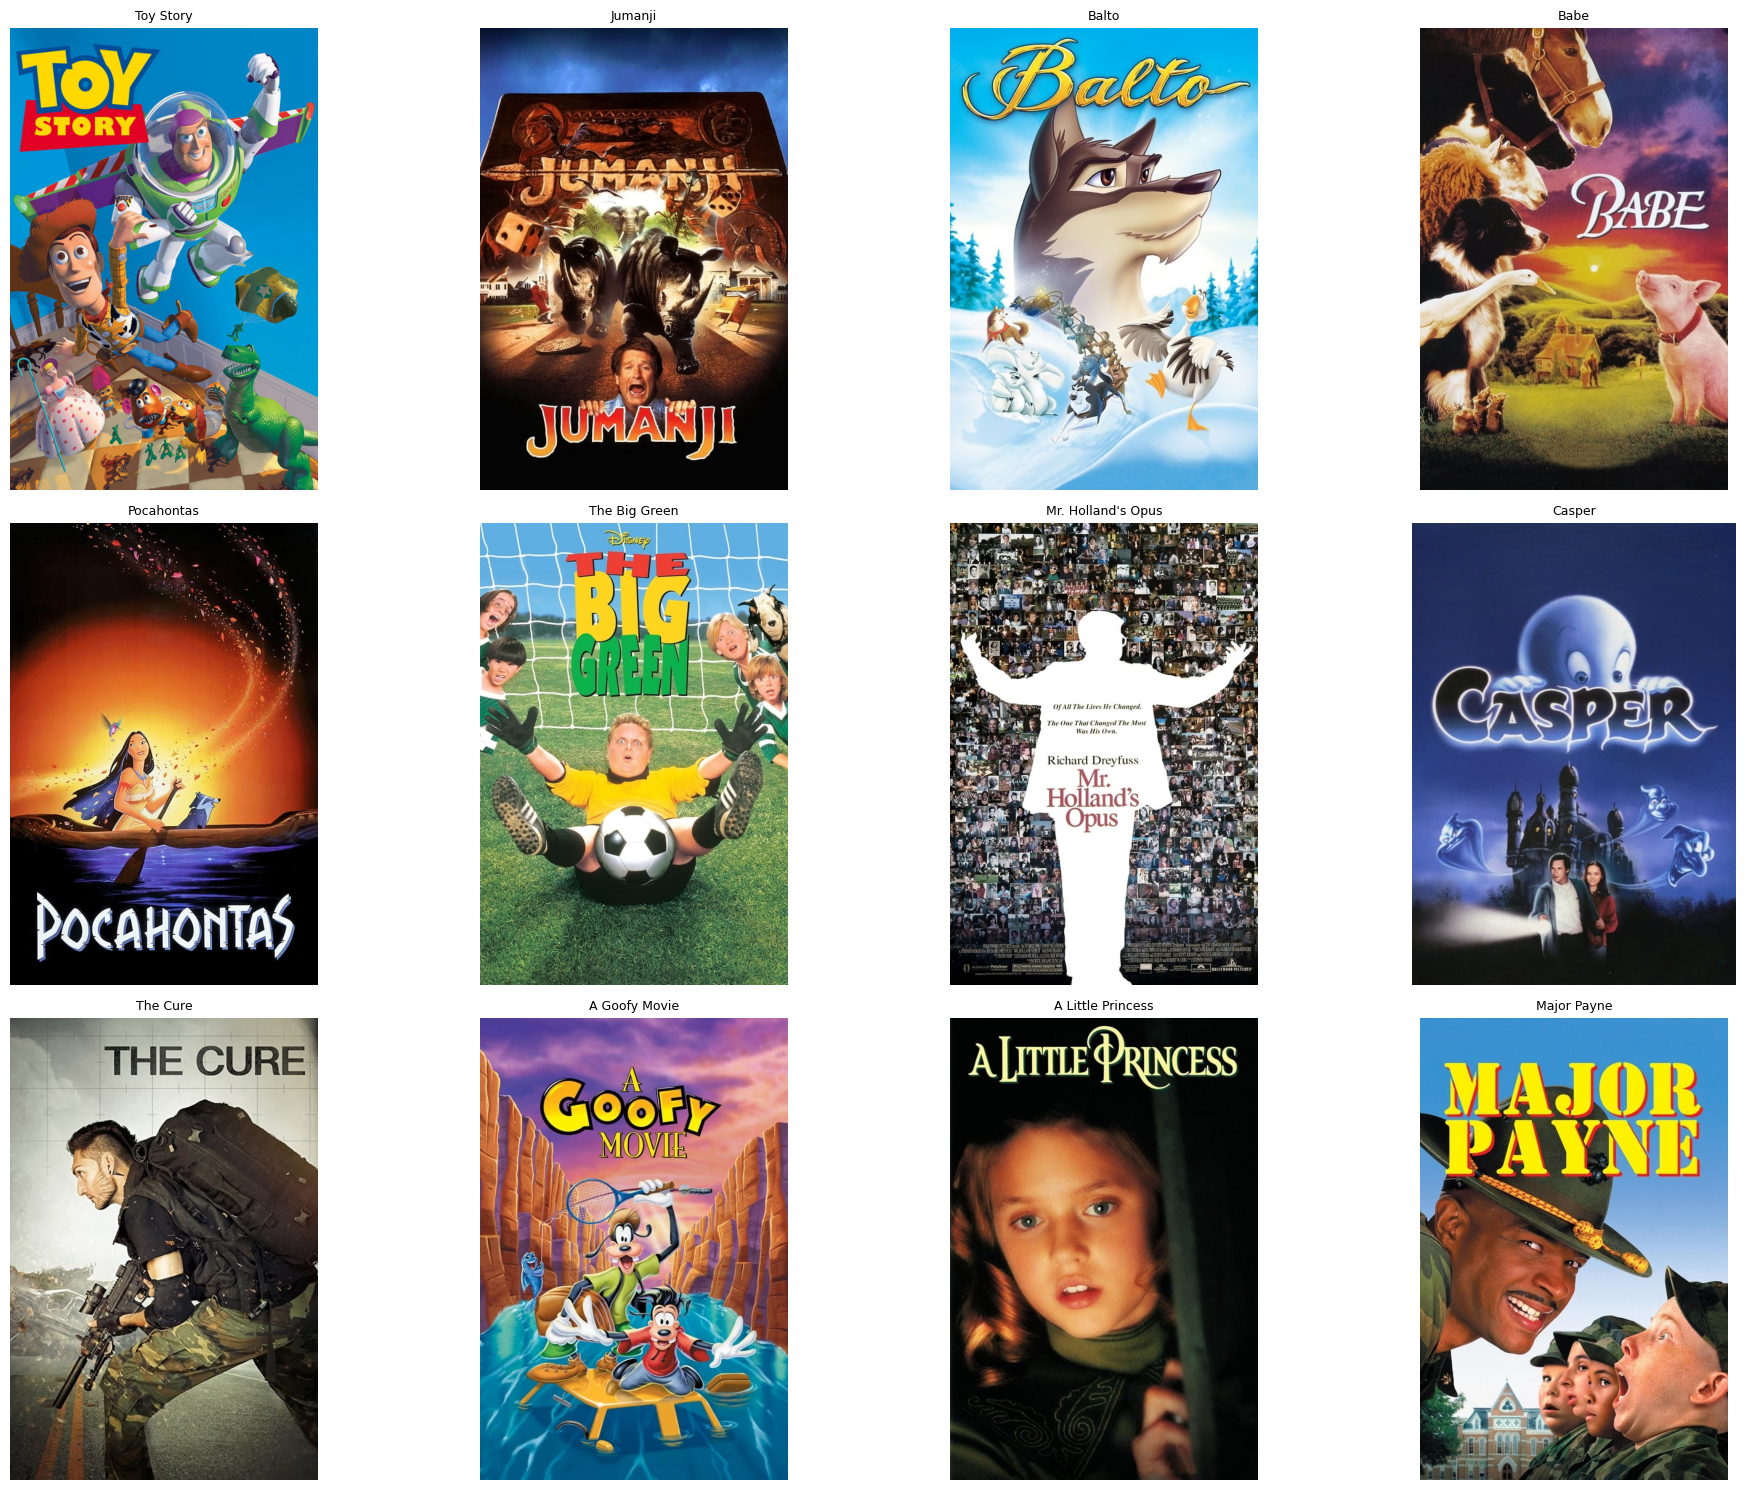

In [ ]:
show_posters_by_predicted_genre("Family")
